In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import smtplib
import requests

<Axes: title={'center': 'Simulated Data with Anomalies'}>

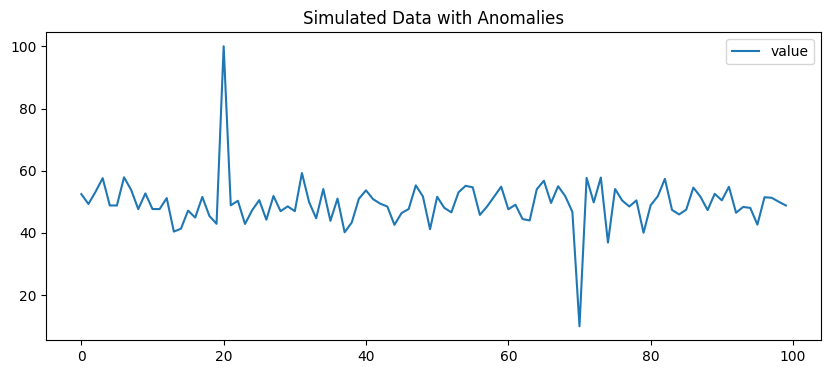

In [12]:
# Simulated normal data
np.random.seed(42)
data = np.random.normal(50, 5, 100)

# Inject anomalies
data[20] = 100   # spike
data[70] = 10    # drop

df = pd.DataFrame({'value': data})
df.plot(figsize=(10,4), title="Simulated Data with Anomalies")

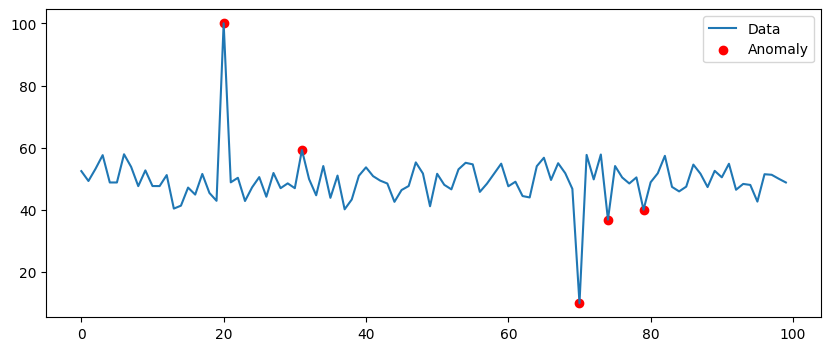

In [13]:
model = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = model.fit_predict(df[['value']])

# -1 = anomaly, 1 = normal
anomalies = df[df['anomaly'] == -1]
plt.figure(figsize=(10,4))
plt.plot(df['value'], label='Data')
plt.scatter(anomalies.index, anomalies['value'], color='red', label='Anomaly')
plt.legend()
plt.show()

In [14]:
def send_email_alert(subject, body, to_email):
    from_email = "your_email@example.com"
    password = "your_password"  # use environment variables in practice
    
    msg = f"Subject: {subject}\n\n{body}"
    with smtplib.SMTP("smtp.gmail.com", 587) as server:
        server.starttls()
        server.login(from_email, password)
        server.sendmail(from_email, to_email, msg)

In [15]:
def send_slack_alert(message, webhook_url):
    payload = {"text": message}
    requests.post(webhook_url, json=payload)

In [16]:
for idx, row in anomalies.iterrows():
    alert_msg = f"Anomaly detected at index {idx}, value={row['value']}"
    
    # Send email
    # send_email_alert("Anomaly Alert", alert_msg, "recipient@example.com")
    
    # Send Slack
    # send_slack_alert(alert_msg, "https://hooks.slack.com/services/XXXX/XXXX/XXXX")
    
    print(alert_msg)

Anomaly detected at index 20, value=100.0
Anomaly detected at index 31, value=59.26139092254469
Anomaly detected at index 70, value=10.0
Anomaly detected at index 74, value=36.901274479551276
Anomaly detected at index 79, value=40.06215542699554
